# Clasificador paisajes
Para este ejercicio vas a crear un clasificador automático de paisajes. Los datos los encontrarás como `seg_train.zip` y `seg_test.zip`. Se pide:
1. Cargar las imágenes. Mira cómo están almacenados los datos. Tendrás que recorrer las carpetas, cargar las imágenes en memoria y etiquetarlas con los nombres de las carpetas. Realiza un reshape de cada imagen (comienza el ejercicio con 32x32, para ir más rápido en las ejecuciones).
2. Investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.
3. Normaliza
4. Diseña la arquitectura de la red. Recuerda que es un algiritmo de clasificación. Ojo con las dimensiones de la entrada
5. Reserva un 20% de los datos del entrenamiento para validar.
6. Representa el objeto history
7. Evalua el modelo con los datos de test
8. Representa algunos de los paisajes donde el modelo comete errores
9. Crea una matriz de confusión con los errores del modelo

**NOTA apartado 1**: para el apartado 1 tendras que recorre las carpetas/imagenes con `os.listdir()`, e ir cargando todas las imagenes como arrays de numpy

**NOTA apartado 4**: empieza con un par de capas Conv2D + MaxPooling2D con activación relu y después la fully connected layer. on softmax como ultima capa

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls /content/drive/MyDrive/Deep_Learning/data_paisajes/

PROF_seg_test.zip  PROF_seg_train.zip


In [4]:
class_names = ['mountain','street','glacier', 'buildings','sea','forest']

IMAGE_SIZE = (100,100)

In [5]:
class_names_label = {class_name:i for i ,class_name in enumerate(class_names)}
class_names_label

{'mountain': 0,
 'street': 1,
 'glacier': 2,
 'buildings': 3,
 'sea': 4,
 'forest': 5}

In [6]:
import zipfile
import os

ruta_zip = "/content/drive/MyDrive/Deep_Learning/data_paisajes/PROF_seg_train.zip"          # Ruta del ZIP
#destino = "carpeta_destino" # Carpeta donde se extraerá

# Crear carpeta destino si no existe
# os.makedirs(destino, exist_ok=True)

with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall()

print("Descompresión de train completada.")

Descompresión de train completada.


In [7]:
import zipfile
import os

ruta_zip = "/content/drive/MyDrive/Deep_Learning/data_paisajes/PROF_seg_test.zip"          # Ruta del ZIP
#destino = "carpeta_destino" # Carpeta donde se extraerá

# Crear carpeta destino si no existe
# os.makedirs(destino, exist_ok=True)

with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall()

print("Descompresión de test completada.")

Descompresión de test completada.


In [33]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

In [9]:
from pathlib import Path


ROOT_PATH = os.getcwd()
TRAIN_PATH = Path(ROOT_PATH) / "seg_train"
TEST_PATH = Path(ROOT_PATH) / "seg_test"

In [10]:
def read_data(path, im_size, class_names_label):
    X = []
    y = []

    for folder in os.listdir(path):
        label = class_names_label[folder]
        folder_path = os.path.join(path,folder)
        # Iterar sobre todo lo que haya en path
        for file in os.listdir(folder_path):
            image_path = os.path.join(folder_path,file)
            image = cv2.imread(image_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            image = cv2.resize(image, im_size)
            X.append(image)
            y.append(label)


    return np.array(X), np.array(y)


X_train, y_train = read_data(TRAIN_PATH, IMAGE_SIZE, class_names_label)
X_test, y_test = read_data(TEST_PATH, IMAGE_SIZE, class_names_label)

print(X_train.shape)
print(X_test.shape)

(14034, 100, 100, 3)
(3000, 100, 100, 3)


In [11]:
print(y_train.shape)
print(y_test.shape)

(14034,)
(3000,)


In [12]:
y_train

array([5, 5, 5, ..., 2, 2, 2])

In [13]:
from sklearn.utils import shuffle

X_train, y_train = shuffle(X_train, y_train, random_state=42)

In [14]:
y_train[0:10]

array([5, 2, 2, 3, 1, 0, 1, 1, 5, 2])

In [15]:
pd.DataFrame(y_train).value_counts()

,count
0,
0,2512
2,2404
1,2382
4,2274
5,2271
3,2191


In [16]:
X_train.max()

np.uint8(255)

street


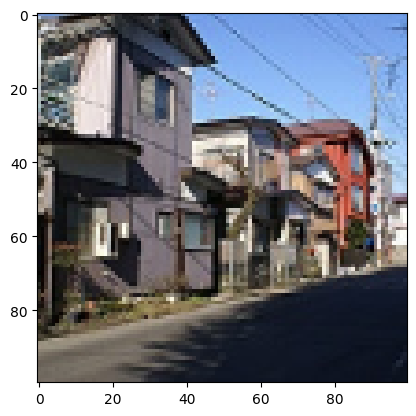

In [17]:
index = np.random.randint(X_train.shape[0])
print(class_names[y_train[index]])
plt.imshow(X_train[index]);

In [18]:
X_train_scal = X_train/255.0
X_test_scal = X_test/255.0

In [19]:
IMAGE_SIZE

(100, 100)

In [20]:
X_train_scal.shape

(14034, 100, 100, 3)

In [ ]:
# 32 filtros convolucionales tamaño 3x3 con activación relu
# maxpooling 2x2
# 64 filtros convolucionales 3x3 activación relu
# maxpooling 2x2
# entrada a la fully connected
# 1 capa con 512 neuronas con activación relu
# capa de salida para clasificar los 6 paisajes

# prográmalo tú :-)

In [27]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1],3)),
    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation="relu"),
    tf.keras.layers.Dense(6, activation="softmax")
])

In [22]:
# Primera capa conv
# 3 porque tenemos 3 capas RGB
# 32 porque hemos elegido en esta capa de convolución hacer 32 filtros
# 3*3 porque en cada filtro tenemos una matriz de 3*3 pixeles
# 32 bias
3*32*3*3 + 32

896

In [23]:
# Segunda capa conv
# 32 porque tenemos 32 filtros en el output de la anterior capa
# 64 porque hemos elegido en esta capa de convolución hacer 64 filtros
# 3*3 porque en cada filtro tenemos una matriz de 3*3 pixeles
# 64 bias
32*64*3*3 + 64

18496

In [24]:
2304*128 + 128

295040

In [28]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    17,334,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,357,254 (66.21 MB)

 Trainable params: 17,357,254 (66.21 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# optimizador Adam, es un clasificador multiclase, mira su accuracy


In [30]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [ ]:
# entreno 30 épocas para conseguir un score cercano a 0.8
# batch 256 limitación de memoria

In [31]:
# batch size de 256, 30 épocas, un 10% para validación
history = model.fit(X_train_scal, y_train, batch_size= 256, epochs=30, validation_split= 0.1)

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 188ms/step - accuracy: 0.5217 - loss: 1.4019 - val_accuracy: 0.6638 - val_loss: 0.9385
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.6990 - loss: 0.8113 - val_accuracy: 0.7258 - val_loss: 0.7448
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.7513 - loss: 0.6882 - val_accuracy: 0.7244 - val_loss: 0.7209
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.7964 - loss: 0.5702 - val_accuracy: 0.7728 - val_loss: 0.6304
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.8369 - loss: 0.4622 - val_accuracy: 0.7607 - val_loss: 0.6451
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.8659 - loss: 0.3885 - val_accuracy: 0.7949 - val_loss: 0.6071
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.8964 - loss: 0.3036 - val_accuracy: 0.7949 - val_loss: 0.5939
Epoch 8/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.9285 - loss: 0.2264 - val_accuracy: 0.7949 -

In [35]:
df_hist = pd.DataFrame(history.history)
df_hist

,accuracy,loss,val_accuracy,val_loss
0,0.521694,1.401946,0.663818,0.938487
1,0.699050,0.811309,0.725783,0.744793
2,0.751306,0.688207,0.724359,0.720899
3,0.796437,0.570196,0.772792,0.630407
4,0.836896,0.462231,0.760684,0.645083
5,0.865875,0.388534,0.794872,0.607148
6,0.896437,0.303555,0.794872,0.593923
7,0.928504,0.226448,0.794872,0.620101
8,0.947031,0.176243,0.789886,0.668328
9,0.959620,0.138966,0.794872,0.741727


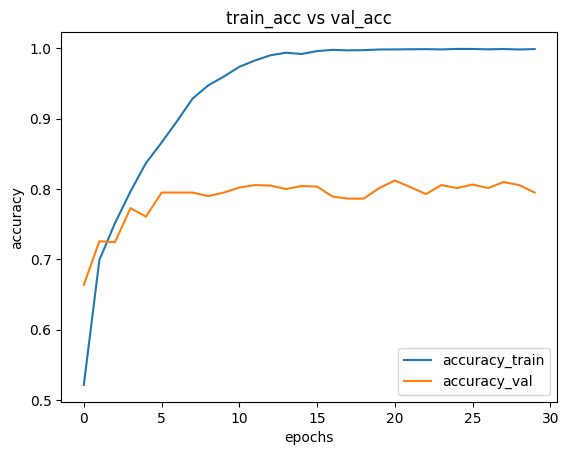

In [36]:
plt.figure()
plt.plot(df_hist['accuracy'], label="accuracy_train")
plt.plot(df_hist['val_accuracy'], label="accuracy_val")
plt.title("train_acc vs val_acc")
plt.ylabel("accuracy")
plt.xlabel("epochs")
plt.legend()

In [37]:
# mira el accuracu en test
results = model.evaluate(X_test_scal, y_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7860 - loss: 1.2219


In [40]:
# obtén la matriz de predicción
predictions = model.predict(X_test_scal)
predictions.round(2)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


array([[0.  , 0.  , 0.  , 0.03, 0.  , 0.97],
       [0.  , 0.  , 0.  , 0.  , 0.  , 1.  ],
       [0.  , 0.  , 0.  , 0.  , 0.  , 1.  ],
       ...,
       [0.02, 0.  , 0.98, 0.  , 0.  , 0.  ],
       [0.  , 0.  , 1.  , 0.  , 0.  , 0.  ],
       [0.67, 0.  , 0.33, 0.  , 0.  , 0.  ]], dtype=float32)

In [41]:
pred_labels = np.argmax(predictions, axis=1)

In [42]:
pred_labels

array([5, 5, 5, ..., 2, 2, 0])

forest


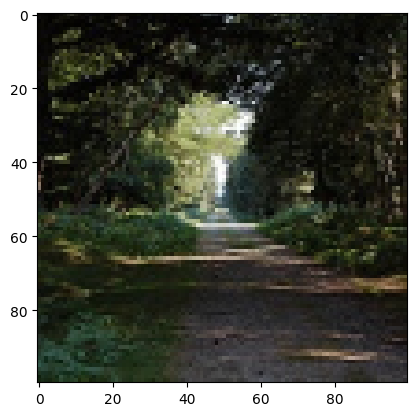

In [44]:
index=3
print(class_names[y_test[index]])
plt.imshow(X_test[index]);

In [45]:
class_names[pred_labels[index]]

'forest'

In [46]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [47]:
class_names_label

{'mountain': 0,
 'street': 1,
 'glacier': 2,
 'buildings': 3,
 'sea': 4,
 'forest': 5}

In [48]:
# matriz de confusión
c_mat = confusion_matrix(y_test, pred_labels)

<Axes: >

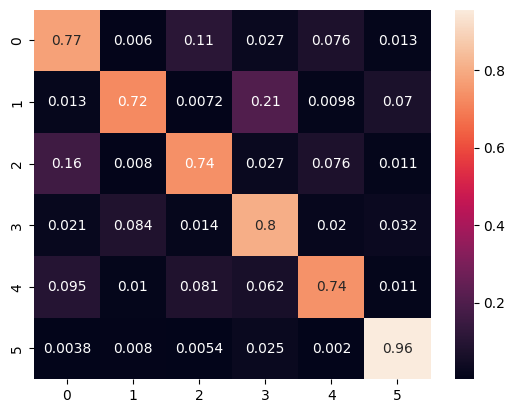

In [49]:
# matriz de confusión
sns.heatmap(c_mat/np.sum(c_mat, axis=1), annot= True)